### Линейная регрессия

In [118]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

In [119]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

In [120]:
# Загрузка данных из CSV-файла
das = pd.read_csv('/content/sample_data/data_about_students.csv', sep=';')

# смотрим описание датасета
print(das.describe())

       Marital status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance  Previous qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000                1.000000   
25%                

In [121]:
# выведем названия столбцов
column_names = das.columns.tolist()
column_names

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

## Названия столбцов:
Marital status (Семейное положение)

Application mode (Способ подачи заявления)

Application order (Очередность заявления)

Course (Номер учебной программы)

Daytime/evening attendance (Посещаемость: дневная/вечерняя(заочная))

Previous qualification (Предыдущая квалификация)

Previous qualification (grade) (Оценка за предыдущую квалификацию)

Nacionality (Национальность)

Mother's qualification (Образование матери)

Father's qualification (Образование отца)

Mother's occupation (Профессия матери)

Father's occupation (Профессия отца)

Admission grade (Проходной балл на поступление в вуз)

Displaced (Перемещенное лицо(беженец или переселенец))

Educational special needs (Особые образовательные потребности)

Debtor (Должен ли за обучение)

Tuition fees up to date (Актуальность оплаты обучения)

Gender (Пол)

Scholarship holder (Получатель стипендии)

Age at enrollment (Возраст на момент зачисления)

International (Иностранный студент)

Curricular units 1st sem (credited) / Curricular units 2nd sem (credited) (Количество учебных дисциплин, которые были зачтены студенту в начале семестра ).

Curricular units 1st sem (enrolled) / Curricular units 2nd sem (enrolled) (Количество учебных дисциплин, на которые студент официально записался в данном семестре.)

Curricular units 1st sem (evaluations) / Curricular units 2nd sem (evaluations) ( Общее количество оценок или аттестаций, полученных студентом в течение семестра.)

Curricular units 1st sem (approved) / Curricular units 2nd sem (approved) ( Количество дисциплин, которые студент успешно сдал в семестре.)

Curricular units 1st sem (grade) / Curricular units 2nd sem (grade) (Средний балл студента по всем сданным дисциплинам за семестр.)

Curricular units 1st sem (without evaluations) / Curricular units 2nd sem (without evaluations) ( Количество дисциплин, по которым студент не был аттестован.)

Unemployment rate (Уровень безработицы)

Inflation rate (Уровень инфляции)

GDP (ВВП)

Target (Статус студента на момент сбора данных.)

Dropout — студент отчислен.

Graduate — студент успешно закончил обучение.

Enrolled — студент все еще учится.

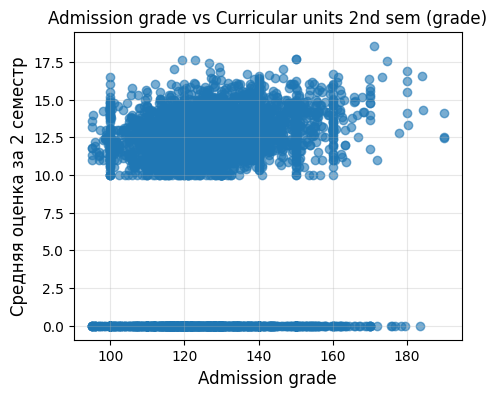

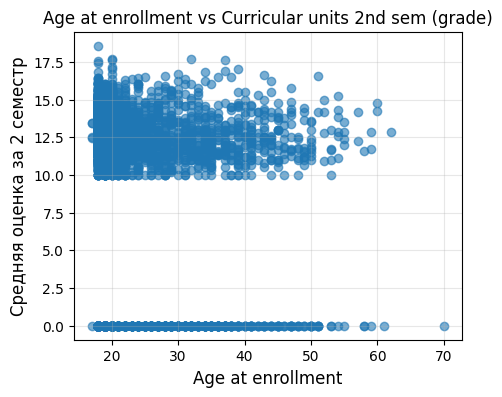

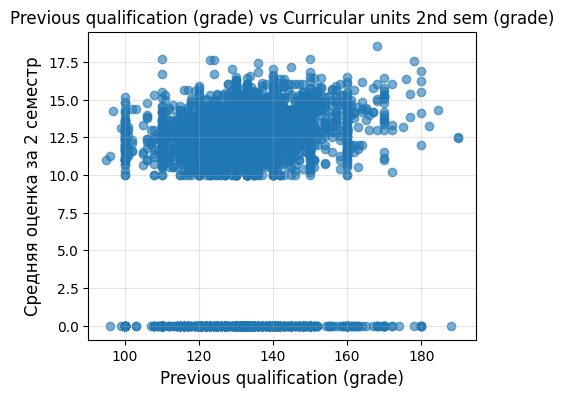

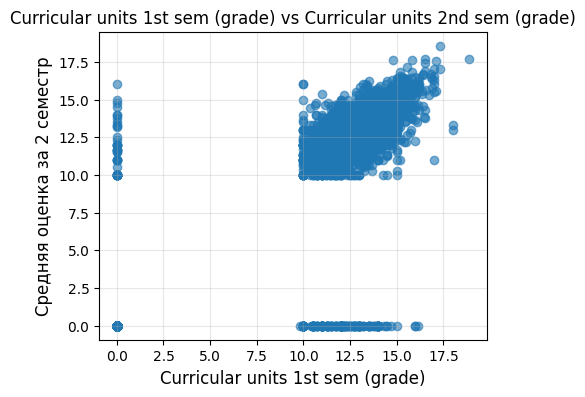

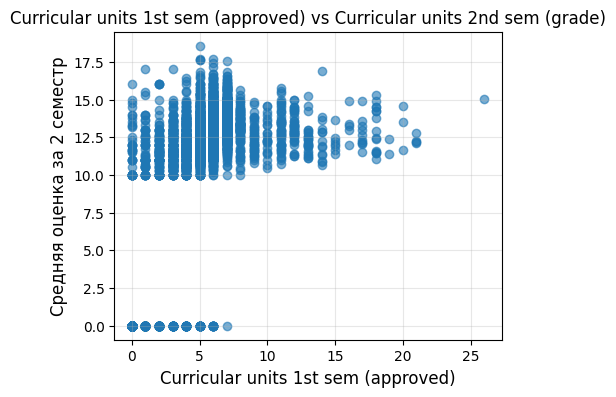

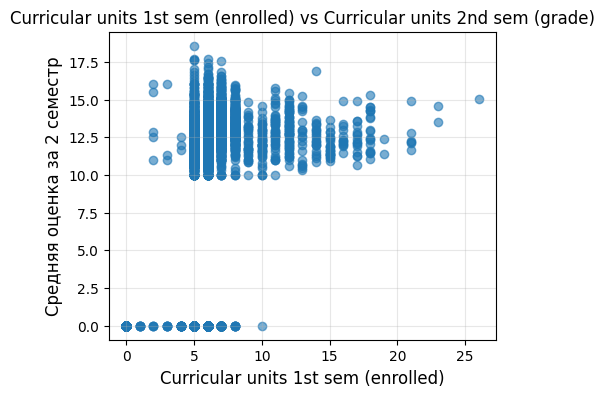

In [122]:
# Определяем признаки (только те, что известны до 2 семестра) и целевую переменную (среднюю оценку в 2 семестре)
feature_names = [
   'Admission grade',
    'Age at enrollment',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (enrolled)',
]

target_name = 'Curricular units 2nd sem (grade)'

# Нарисуем диаграммы рассеяния для каждого признака
for index, feature_name in enumerate(feature_names):
    plt.figure(figsize=(5, 4))
    plt.scatter(das[feature_name], das[target_name], alpha=0.6)
    plt.ylabel('Средняя оценка за 2 семестр', size=12)
    plt.xlabel(feature_name, size=12)
    plt.title(f'{feature_name} vs {target_name}')
    plt.grid(True, alpha=0.3)
    plt.show()

In [123]:
# подготавливаем датасет к обучению
X = das[feature_names]
y = das[target_name]
print(f'X shape: {X.shape} | y shape: {y.shape}')

X shape: (4424, 6) | y shape: (4424,)


In [124]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [125]:
X_train

,Admission grade,Age at enrollment,Previous qualification (grade),Curricular units 1st sem (grade),Curricular units 1st sem (approved),Curricular units 1st sem (enrolled)
4375,100.0,27,161.0,0.000000,0,5
3642,118.0,20,133.1,11.666667,6,6
311,118.9,21,133.1,11.333333,3,6
1281,115.5,20,133.1,13.024286,7,8
4391,130.0,32,130.0,13.761111,7,7
...,...,...,...,...,...,...
3271,113.5,50,133.1,13.250000,8,9
2715,104.5,21,101.0,13.336000,5,7
2204,146.2,18,143.0,13.200000,5,6
2693,138.3,18,140.0,16.000000,6,6


In [126]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()
modelLR.fit(X_train, y_train)
y_pr_LR = modelLR.predict(X_test)

In [127]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  2.7007
  R2: 0.7297
 Adjusted R2: 0.7278
 Cross Validated R2: 0.7294


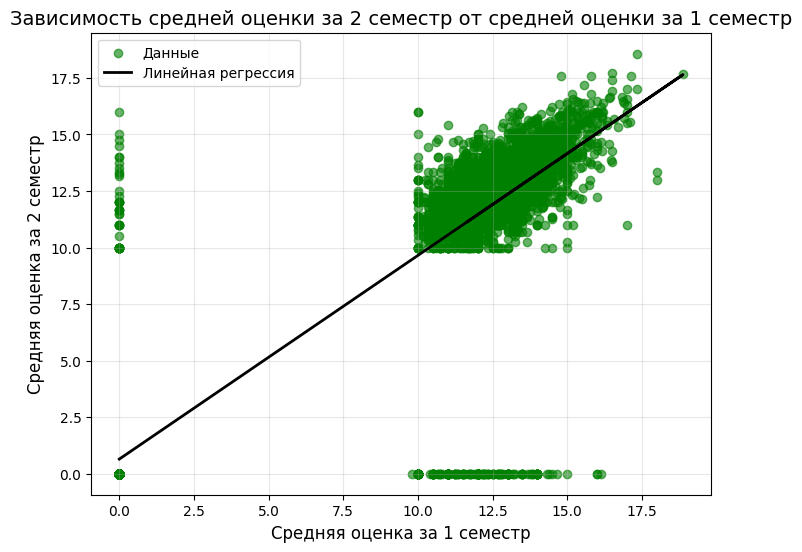

In [128]:
# попробуем отрисовать, как выглядит наша линейная регрессия
# Используем один из признаков для визуализации (например, входной балл)

X2 = das['Curricular units 1st sem (grade)'].values[:, np.newaxis]
y2 = das['Curricular units 2nd sem (grade)'].values

model2 = LinearRegression()
model2.fit(X2, y2)

plt.figure(figsize=(8, 6))
plt.scatter(X2, y2, color='g', alpha=0.6, label='Данные')
plt.plot(X2, model2.predict(X2), color='k', linewidth=2, label='Линейная регрессия')
plt.ylabel('Средняя оценка за 2 семестр', size=12)
plt.xlabel('Средняя оценка за 1 семестр', size=12)
plt.title('Зависимость средней оценки за 2 семестр от средней оценки за 1 семестр', size=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* Линейная регрессия показала хороший результат (R² = 0.73)

* Модель объясняет 73% дисперсии целевой переменной

* Разница между R² и Adjusted R² - небольшая (0.019), что говорит об отсутствии сильного переобучения

* Cross-validation подтверждает стабильность модели (CV R² = 0.73)

Вывод: Линейная регрессия — хороший базовый вариант, но есть пространство для улучшения

### Полиномиальная регрессия

In [129]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.2, random_state=15)

In [130]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  2.4959
  R2: 0.7691
 Adjusted R2: 0.7452
 Cross Validated R2: 0.7529


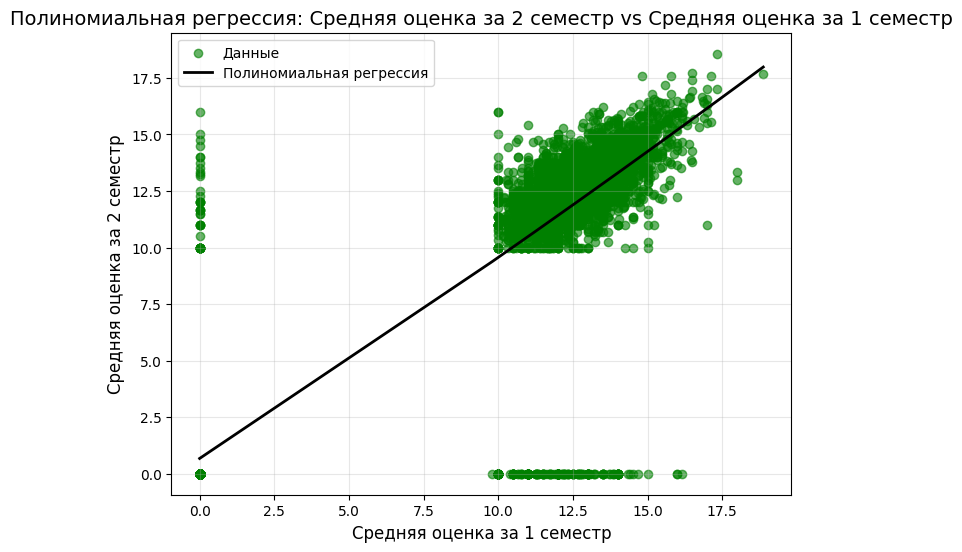

In [131]:
# Выбираем один признак для визуализации (входной балл)
X2 = das['Curricular units 1st sem (grade)'].values[:, np.newaxis]  # ← 2D массив (n, 1)
y2 = das['Curricular units 2nd sem (grade)'].values

# Создаём полиномиальные признаки
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X2)

# Обучаем модель
model2 = LinearRegression()
model2.fit(poly_features, y2)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X2, y2, color='g', alpha=0.6, label='Данные')

# Сортируем для красивой линии регрессии
X2_sorted = np.sort(X2, axis=0)
plt.plot(X2_sorted, model2.predict(poly.transform(X2_sorted)), color='k', linewidth=2, label='Полиномиальная регрессия')

plt.ylabel('Средняя оценка за 2 семестр', size=12)
plt.xlabel('Средняя оценка за 1 семестр', size=12)
plt.title('Полиномиальная регрессия: Средняя оценка за 2 семестр vs Средняя оценка за 1 семестр', size=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* Модель объясняет 77% дисперсии целевой переменной - это лучший результат среди всех моделей.
* Высокий R² на тесте (0.77) и соответственно высокий Adjusted R² (0.75) — явный признак отсутствия переобучения.
* Разница между R² и Adjusted R² - небольшая (0.021), что говорит о стабильности модели.
* Высокий Cross Validated R² (0.75) подтверждает отсутствие переобучения.

Вывод: Полиномиальная регрессия - лучший вариант, рекомендуется к использованию.

### Регрессия дерева принятия решений

In [146]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  3.656
  R2: 0.5046
 Adjusted R2: 0.5012
 Cross Validated R2: 0.5043


* Decision Tree показал худший результат среди протестированных моделей (R² = 0.51)
* Разница между R² и Adjusted R² (0.03) - невелика, но по маленькому Cross Validated R2 (0.50) можно понять, что произошло переобучение.

Вывод: Требуется настройка гиперпараметров (max_depth, min_samples_split) для улучшения работы

### Регрессия случайного леса

In [147]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  2.5943
  R2: 0.7506
 Adjusted R2: 0.7489
 Cross Validated R2: 0.7252


* Random Forest показал средний результат среди всех моделей (R² = 0.75)
* Модель объясняет 75% дисперсии целевой переменной.
* Разница между R² и Adjusted R² (0.017) — модель наиболее стабильна.

Вывод: Случайный лес - тоже хороший вариант, на уровне линейной регрессии.

### Регрессия опорных векторов (SVR)

In [151]:
# Create a support vector regression model
# Оптимизированная SVR
modelSVR = SVR(
    kernel='linear',
    C=1.0,
    epsilon=0.1,
    max_iter=1000,
    cache_size=200  # Кэш для ускорения
)
modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)

In [152]:
_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  8.3088
  R2: -1.5586
 Adjusted R2: -1.5761
 Cross Validated R2: -9.0472


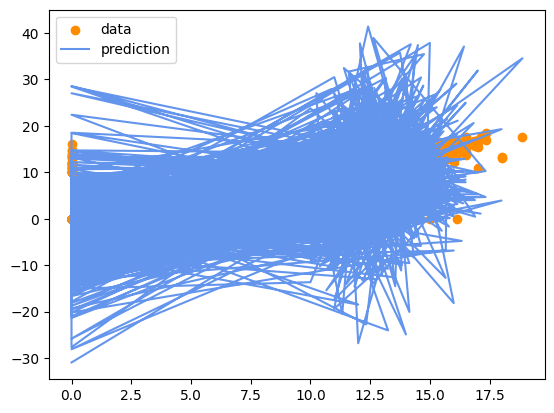

In [153]:
plt.scatter(X_train['Curricular units 1st sem (grade)'], y_train, color='darkorange',
            label='data')
plt.plot(X_train['Curricular units 1st sem (grade)'], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

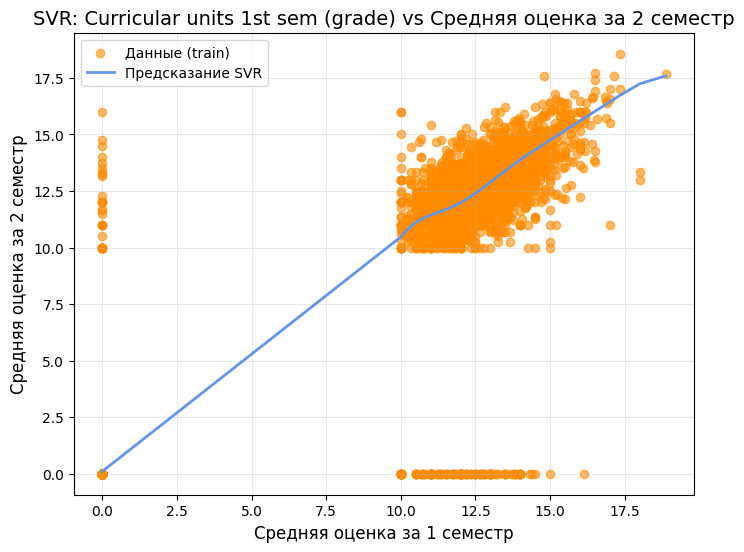

In [154]:
# Выбираем один признак для визуализации (например, средняя оценка за 1 семестр)
feature = 'Curricular units 1st sem (grade)'

# Для визуализации: берем только один признак из тренировочных данных
X_train_1d = X_train[[feature]]  # ← DataFrame (n, 1), а не Series!
X_test_1d = X_test[[feature]]

# Обучаем SVR модель на одном признаке (если еще не обучена)
modelSVR_1d = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
modelSVR_1d.fit(X_train_1d, y_train)

# Предсказания
y_train_pred = modelSVR_1d.predict(X_train_1d)

# Сортируем данные для красивой линии
X_sorted = np.sort(X_train_1d.values, axis=0)
y_sorted_pred = modelSVR_1d.predict(X_sorted)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X_train_1d, y_train, color='darkorange', alpha=0.6, label='Данные (train)')
plt.plot(X_sorted, y_sorted_pred, color='cornflowerblue', linewidth=2, label='Предсказание SVR')

plt.xlabel('Средняя оценка за 1 семестр', size=12)
plt.ylabel('Средняя оценка за 2 семестр', size=12)
plt.title(f'SVR: {feature} vs Средняя оценка за 2 семестр', size=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [155]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  2.9376
  R2: 0.6802
 Adjusted R2: 0.678
 Cross Validated R2: 0.6886


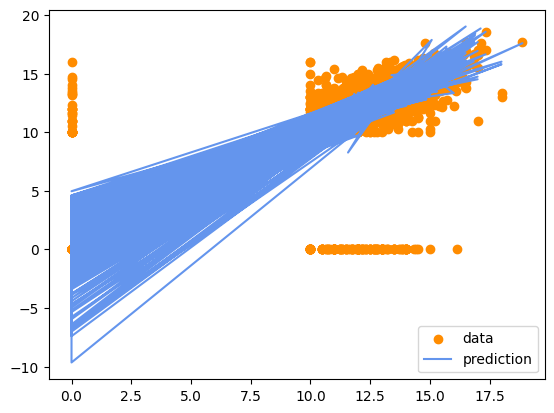

In [156]:
plt.scatter(X_train['Curricular units 1st sem (grade)'], y_train, color='darkorange',
            label='data')
plt.plot(X_train['Curricular units 1st sem (grade)'], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [157]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  2.917
  R2: 0.6846
 Adjusted R2: 0.6825
 Cross Validated R2: 0.6613


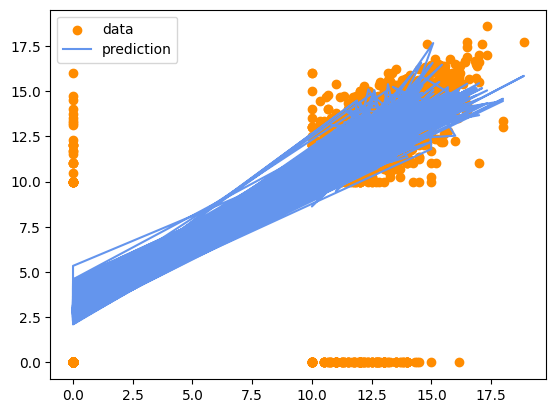

In [158]:
plt.scatter(X_train['Curricular units 1st sem (grade)'], y_train, color='darkorange',
            label='data')
plt.plot(X_train['Curricular units 1st sem (grade)'], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

* Оптимизированный SVR показал худший результат (R² = -1.55)
* Отрицательный Adjusted R² указывает на сильное переобучение или некорректную настройку

Вывод: Оптимизированный SVR не подходит для данного датасета

### Регрессия ElasticNet

In [159]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  2.7041
  R2: 0.729
 Adjusted R2: 0.7271
 Cross Validated R2: 0.7291


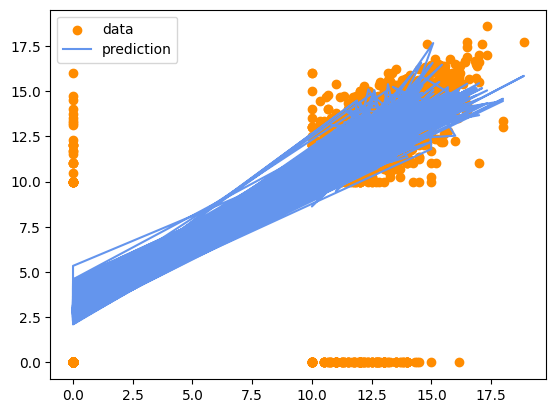

In [160]:
plt.scatter(X_train['Curricular units 1st sem (grade)'], y_train, color='darkorange',
            label='data')
plt.plot(X_train['Curricular units 1st sem (grade)'], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

Выводы:
ElasticNet сочетает L1 и L2 регуляризацию

**Вывод:**

* Лучшая модель: Полиномиальная регрессия
* Наилучшие метрики (R² = 0.77, RMSE = 2.5)
* Крайне стабильная модель (одна из минимальных разниц между R² и CV R²)